In [12]:
# 11/2025
###########################################################################################
# using linear model to test correlation
#	Testing correlation
#   Plotting results
#   Diagnostics of the model
#   non-parametric alternative if necessary (not yet implemented)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
curRoot = 'C'  # 'C' or 'D'
curProject = 'ataxia'

In [53]:
#########  how many of each SCA has Age_onset info?  #########

info_name = f'{curRoot}:/B_projWIP/proj_{curProject}/SCA_INFO/processed_INFO/ATRIL_BIOSCA_CERMOI_time1_only.csv'
info_df = pd.read_csv(info_name, index_col=0, header=0)
sca_values = info_df.loc[info_df['Age_onset'].notnull(), 'SCA']
print(sca_values.value_counts().sort_index())

info_df.value_counts()

SCA
1    16
2    21
3    18
7    20
Name: count, dtype: int64


Series([], Name: count, dtype: int64)

In [143]:
######################################  testing models  #######################################

file_name = f'{curRoot}:/B_projWIP/proj_{curProject}/Champollion/Atril_Biosca_Cermoi_iso_u_with_info_sca_7/SC-sylv_right_name06-17-02--84_embeddings_iso_u_INFO.csv'
cur_info = pd.read_csv(file_name, index_col=0, header=0)

# Check if your brain measure actually has variation
print(f"Variance of iso_dim1_neig30: {cur_info['iso_dim1_neig30'].var()}")

# Check if SCA still has two groups in the FINAL dataframe
print(f"Unique SCA values in model: {cur_info['SCA'].unique()}")
print(cur_info['SCA'].value_counts())

print(pd.crosstab(cur_info['SCA'], cur_info['Sex']))  # Check Sex distribution        
print(cur_info.groupby('SCA')['Age'].describe())  # Check Age overlap

"""
# Model 1: Only the Brain vs SCA (No covariates)
# If this gives a real p-value, then Age or Sex is the problem.
res1 = smf.ols(f'iso_dim1_neig30 ~ C(SCA)', data=cur_info).fit()
print(f"P-value (SCA only): {res1.pvalues['C(SCA)[T.1]']}")

# Model 2: Add Age
res2 = smf.ols(f'iso_dim1_neig30 ~ C(SCA) + Age', data=cur_info).fit()
print(f"P-value (SCA + Age): {res2.pvalues['C(SCA)[T.1]']}")

# Model 3: Add Sex
res3 = smf.ols(f'iso_dim1_neig30 ~ C(SCA) + Age + C(Sex)', data=cur_info).fit()
print(f"P-value (Full Model): {res3.pvalues.get('C(SCA)[T.1]', 'ERROR')}")
"""

Variance of iso_dim1_neig30: 15058.194775262626
Unique SCA values in model: [7 0]
SCA
0    27
7    26
Name: count, dtype: int64
Sex   1   2
SCA        
0    13  14
7    13  13
     count       mean        std   min   25%   50%   75%   max
SCA                                                           
0     27.0  47.518519  13.054237  26.0  36.5  46.0  59.5  67.0
7     26.0  42.846154  13.739555  18.0  33.5  44.5  51.0  76.0


'\n# Model 1: Only the Brain vs SCA (No covariates)\n# If this gives a real p-value, then Age or Sex is the problem.\nres1 = smf.ols(f\'iso_dim1_neig30 ~ C(SCA)\', data=cur_info).fit()\nprint(f"P-value (SCA only): {res1.pvalues[\'C(SCA)[T.1]\']}")\n\n# Model 2: Add Age\nres2 = smf.ols(f\'iso_dim1_neig30 ~ C(SCA) + Age\', data=cur_info).fit()\nprint(f"P-value (SCA + Age): {res2.pvalues[\'C(SCA)[T.1]\']}")\n\n# Model 3: Add Sex\nres3 = smf.ols(f\'iso_dim1_neig30 ~ C(SCA) + Age + C(Sex)\', data=cur_info).fit()\nprint(f"P-value (Full Model): {res3.pvalues.get(\'C(SCA)[T.1]\', \'ERROR\')}")\n'

In [352]:
################################  LM stats, print SORTED output to summary file  ##################################
# Note: The cur_SCA must be specified as 1,2,3 or 7
#       It doesn't work for now if we want to run stats on all the SCAs together. 

from pathlib import Path
output_filename = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Stats_printout\LM_summaries.txt'

################ Define the diag measures  ################
diag_measures = ['CAG']  # ['SCA', 'CAG','SARA','INAS']
# Complete list: ['RANDOMIZATION', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS', 'CodeICM', 'Age_onset', 'CCFS', 'Handedness', 'Disease_duration', 
#  'allele1', 'allele2', 'minAllele', 'maxAllele', 'sumAllele']           
################ Define the shape measures  ################
#shape_measures = ['iso_dim1_neig5','iso_dim2_neig5','iso_dim3_neig5']  
#shape_measures = ['iso_dim1_neig10','iso_dim2_neig10','iso_dim3_neig10']  
shape_measures = ['iso_dim1_neig30','iso_dim2_neig30','iso_dim3_neig30']  
#shape_measures = ['iso_dim1_neig5', 'iso_dim2_neig5', 'iso_dim3_neig5', 'iso_dim1_neig30', 'iso_dim2_neig30', 'iso_dim3_neig30','u_dim1_neig10', 'u_dim1_neig30', 'u_dim2_1_neig10', 'u_dim2_2_neig10', 'u_dim2_1_neig30', 'u_dim2_2_neig30']
#shape_measures = ['iso_dim1_neig10', 'iso_dim2_neig10', 'iso_dim3_neig10', 'iso_dim1_neig30', 'iso_dim2_neig30', 'iso_dim3_neig30','u_dim1_neig10', 'u_dim1_neig30', 'u_dim2_1_neig10', 'u_dim2_2_neig10', 'u_dim2_1_neig30', 'u_dim2_2_neig30']

###################################  Define patient/SCA related params ####################################
## filtering pipeline that allows toggling between a specific clinical study focus and a broad dataset view ##
CONTROL_SITE_RULES = {  # Rulebook: Which control sites are allowed for a specific SCA group
    1: ['BIOSCA'],
    2: ['BIOSCA', 'CERMOI'],
    3: ['BIOSCA'],
    7: ['BIOSCA', 'CERMOI']
}
# True when diag measure is CAG or other that involves ONLY patients
PATIENT_ONLY = False
# True when shape measure is calculated by using a specific SCA+Control, not the whole set
SCA_SPECIFIC_DATA = True
# True when need filtering for specific sca/controls is needed
USE_FILTERED_DATA = False  
# Define the SCA type
cur_SCA = 3
# The specific sca dir to store the data 
# NOTE: for sca2, when Atril is added to the original sca2 set, the dir is 102 instead of 2
cur_SCA_dir = 3 
# Decide the dir Path depending on all set or sca-specific set
if SCA_SPECIFIC_DATA == False:
    path_string = f'{curRoot}:/B_projWIP/proj_{curProject}/Champollion/Atril_Biosca_Cermoi_iso_u_with_DB_INFO/' # all sca together
else:
    path_string = f'{curRoot}:/B_projWIP/proj_{curProject}/Champollion/Atril_Biosca_Cermoi_iso_u_with_info_sca_{cur_SCA_dir}/'  
# CONVERT THE STRING TO A PATH OBJECT
input_directory = Path(path_string)  

#######################################################################################################################################
results_list = [] # Create a list to store results
for csv_file_path in input_directory.glob('*.csv'):
    try:
        print(f"Processing: {csv_file_path.name}")
        cur_info = pd.read_csv(csv_file_path, index_col=0, header=0)
        ###############################  active_df: filtering data according to SCA  ##############################
        allowed_sites = CONTROL_SITE_RULES.get(cur_SCA, ['BIOSCA']) # default to Biosca
        is_patient = (cur_info['SCA'] == cur_SCA)
        is_control = (cur_info['SCA'] == 0) & (cur_info['CodeICM'].isin(allowed_sites))
        condition = is_patient | is_control
        if PATIENT_ONLY:
            condition = is_patient        
        filtered_df = cur_info[condition]    # Apply the condition to the dataframe    
        ###########  define the active_df to be used in the final Linear Model  ###########
        if USE_FILTERED_DATA:
            active_df = filtered_df  
            data_label = "FILTERED"  # data_label used as part of the header in the output file of the result printout
        else:
            active_df = cur_info
            data_label = "FULL DATASET"        
        ############################################################################################################
        
        for shape_measure in shape_measures:
            print(shape_measure)
            for diag_measure in diag_measures:
                #formula = f'{shape_measure} ~ {diag_measure}'     
                formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex)'     
                #formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex)'    # for specific diag_measure SCA, diff SCA vs Ctl
                #formula = f'{shape_measure} ~ C({diag_measure}) + Age + C(Sex) + C(CodeICM)' 
                #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + Age_onset'                
                #formula = f'{shape_measure} ~ {diag_measure} + Age + C(Sex) + C(CodeICM)'  # for specific diag_measure CAG, cor form & CAG
                #formula = f'{shape_measure} ~ {diag_measure} + C(SCA) + Age + C(Sex) + C(CodeICM)' # diag_measure CAG, cor form & CAG
               
                model = smf.ols(formula, data = active_df).fit()         

                ##############  find the diag_measure in the report, continuous or categorical  ###############
                # "search-and-capture" mission. 
                # looking through the output of the statistical model to find the specific variable we are interested in, 
                #   regardless of how the model decided to name it.
                ############ Get all variable names the model actually calculated  ############
                all_model_vars = model.pvalues.index   
                # Identify the correct key.
                # Continuous Variables: If diag_measure is "SARA", the model output key is simply SARA.
                # Categorical Variables: If we use a formula like C(Sex), the model expands this into "Dummy Variables." 
                # Instead of Sex, the key becomes something like C(Sex)[T.1] or C(Sex)[T.MALE].
                # Example: SARA, CAG (continous), or C(Sex)[T.1] (categorical)
                matching_keys = [k for k in all_model_vars if k == diag_measure or k.startswith(f'C({diag_measure})')]
                if matching_keys:                    
                    target_key = matching_keys[0]  # Use the first match found 
                    p_val = model.pvalues[target_key]
                else: # Fallback if the variable was dropped during modelling due to Collinearity or Missing from the input set               
                    p_val = 1.0 
                
                ###################### Result file header  ######################
                header = (
                    f'================ {data_label} | {csv_file_path.name} | '
                    f'{shape_measure} | p({diag_measure}): {p_val:.6f} ================\n'
                )
                ############# Store the data as a dictionary: p_value and text_summary  #############
                results_list.append({
                    'p_value': p_val,
                    'text_summary': header + model.summary().as_text() + '\n\n'
                })
    except Exception as e:
        print(f"Error reading {csv_file_path.name}: {e}")

# Sort the list by the p_value key (smallest to largest)
results_list.sort(key=lambda x: x['p_value'])
# Write the sorted results stored in 'text_summary' to the output file
with open(output_filename, 'w') as f_all:
    for item in results_list:
        f_all.write(item['text_summary'])

print(f"Done! Results written to {output_filename}")

Processing: FCLp-subsc-FCLa-INSULA_left_name17-43-58--232_embeddings_iso_u_INFO.csv
iso_dim1_neig30
iso_dim2_neig30
iso_dim3_neig30
Processing: FCLp-subsc-FCLa-INSULA_right_name17-47-16--166_embeddings_iso_u_INFO.csv
iso_dim1_neig30
iso_dim2_neig30


C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


iso_dim3_neig30
Processing: FCMpost-SpC_left_name06-21-10--231_embeddings_iso_u_INFO.csv
iso_dim1_neig30
iso_dim2_neig30
iso_dim3_neig30
Processing: FCMpost-SpC_right_name06-34-24--229_embeddings_iso_u_INFO.csv


C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


iso_dim1_neig30
iso_dim2_neig30
iso_dim3_neig30
Processing: FColl-SRh_left_name06-43-43--210_embeddings_iso_u_INFO.csv
iso_dim1_neig30
iso_dim2_neig30


...

C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


iso_dim1_neig30
iso_dim2_neig30
iso_dim3_neig30
Processing: STs_left_name08-32-58--223_embeddings_iso_u_INFO.csv
iso_dim1_neig30
iso_dim2_neig30


C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


iso_dim3_neig30
Processing: STs_right_name08-32-58--52_embeddings_iso_u_INFO.csv
iso_dim1_neig30
iso_dim2_neig30
iso_dim3_neig30
Done! Results written to C:\B_projWIP\proj_ataxia\Champollion\Stats_printout\LM_summaries.txt


C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joyca\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


In [335]:
#############################  Boxplots of selected regions for sca 2 #############################

import re  # for regular expressionsm selecting the part of the region name

cur_SCA = 2
cur_regions = ["FPO-SCu-ScCal_right_name07-15-26--174_embeddings","Lobule_parietal_sup_left_name07-23-04--36_embeddings",
               "ScCal-SLi_right_name07-54-42--78_embeddings","SsP-SPaint_right_name08-29-38--71_embeddings" ]
path_string = f'{curRoot}:/B_projWIP/proj_{curProject}/Champollion/Atril_Biosca_Cermoi_iso_u_with_info_sca_{cur_SCA}/'  
input_directory = Path(path_string)  # CONVERT THE STRING TO A PATH OBJECT

results_list = []
for csv_file_path in input_directory.glob('*.csv'):
    # Check if the filename contains any of the strings in cur_regions
    if any(region_str in csv_file_path.name for region_str in cur_regions):
        try:
            print(f"Processing: {csv_file_path.name}")
            df = pd.read_csv(csv_file_path)
            
            # Select the columns needed
            subset = df[['subjID', 'iso_dim3_neig30', 'SCA']].copy() # Select 'iso_dim3_neig30'
            
            # Add a 'region' column so we know where the data came from 
            clean_name = csv_file_path.stem    # Strip the extension to keep the name clean
            clean_name = re.sub(r'(left|right).*', r'\1', clean_name)  # remove rest of the name after left/right
            subset['region'] = clean_name
            
            results_list.append(subset)
            
        except Exception as e:
            print(f"Error processing {csv_file_path.name}: {e}")

# Combine all regions into one master DataFrame
final_df = pd.concat(results_list, ignore_index=True)


Processing: FPO-SCu-ScCal_right_name07-15-26--174_embeddings_iso_u_INFO.csv
Processing: Lobule_parietal_sup_left_name07-23-04--36_embeddings_iso_u_INFO.csv
Processing: ScCal-SLi_right_name07-54-42--78_embeddings_iso_u_INFO.csv
Processing: SsP-SPaint_right_name08-29-38--71_embeddings_iso_u_INFO.csv


C:\Users\joyca\AppData\Local\Temp\ipykernel_3148\3239019449.py:6: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=final_df, x='region', y='iso_dim3_neig30', hue='SCA', dodge=True, color='black', alpha=0.5, legend=False)


C:\B_projWIP\proj_ataxia\Champollion\Plots\ataxia_sca2_significant_regions.png


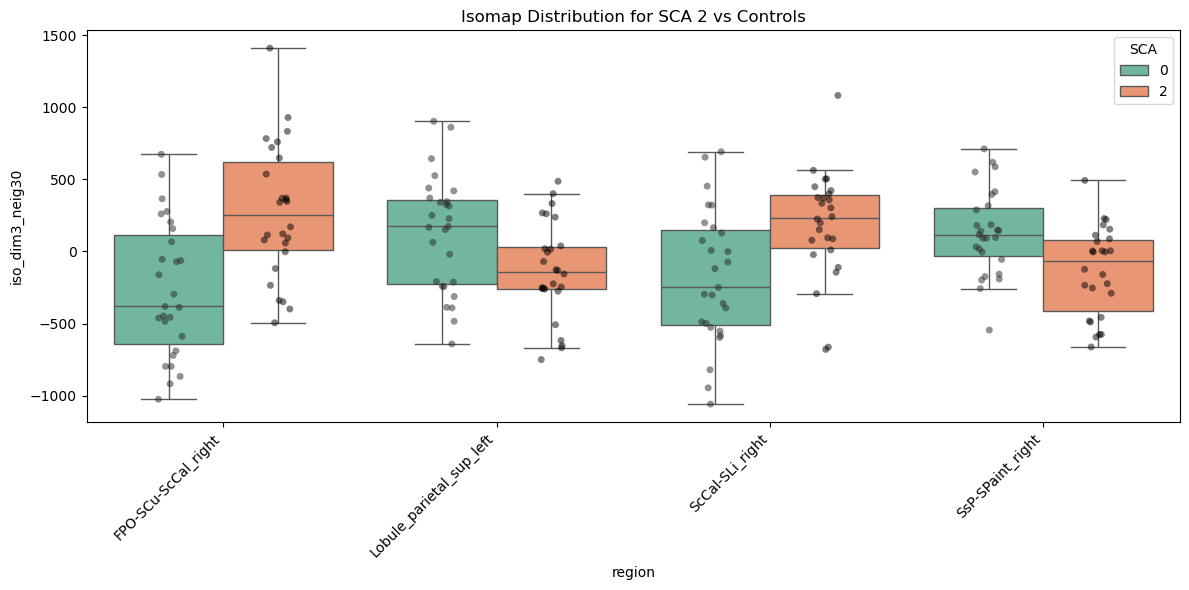

In [339]:
##############################  plotting the above selected data  ###############################
plt.figure(figsize=(12, 6))

# Plotting by region on X-axis, Isomap value on Y-axis, colored by SCA
sns.boxplot(data=final_df, x='region', y='iso_dim3_neig30', hue='SCA', palette='Set2', showfliers=False)
sns.stripplot(data=final_df, x='region', y='iso_dim3_neig30', hue='SCA', dodge=True, color='black', alpha=0.5, legend=False)

plt.xticks(rotation=45, ha='right')
plt.title(f'Isomap Distribution for SCA {cur_SCA} vs Controls')
plt.tight_layout()

curPlotName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Plots\{curProject}_sca2_significant_regions.png'
print(curPlotName)
#plt.savefig(curPlotName, dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
##########################  Old: Quick first analysis testing Atril Champollion files  ###########################

In [ ]:
from pathlib import Path

############### WIP data selection: eg. by study ###############
diag_measures = ['CAG']  # ['CAG','SARA','INAS']
# complete list: 
# ['RANDOMIZATION', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS', 'CodeICM', 'Age_onset', 'CCFS', 'Handedness', 'Disease_duration', 
#  'allele1', 'allele2', 'minAllele', 'maxAllele', 'sumAllele']
shape_measures = ['iso_dim1_neig10']  
# complete list
# ['iso_dim1_neig10', 'iso_dim2_neig10', 'iso_dim3_neig10', 'iso_dim1_neig30', 'iso_dim2_neig30', 'iso_dim3_neig30', 
# 'u_dim1_neig10', 'u_dim1_neig30', 'u_dim2_1_neig10', 'u_dim2_2_neig10', 'u_dim2_1_neig30', 'u_dim2_2_neig30']

model_results = {}    # Dictionary to store results
output_filename = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\Stats_printout\{shape_measures}_LM_summaries.txt'

path_string = f'{curRoot}:/B_projWIP/proj_{curProject}/Champollion/Atril_Biosca_Cermoi_iso_u_with_DB_INFO/'
input_directory = Path(path_string)  # CONVERT THE STRING TO A PATH OBJECT
for csv_file_path in input_directory.glob('*.csv'):
    try:
        print(csv_file_path)
        cur_info = pd.read_csv(csv_file_path,index_col=0,header=0)

        with open(output_filename, 'w') as f:            
            for shape_measure in shape_measures:
                for diag_measure in diag_measures:        
                    formula = f'{shape_measure} ~ {diag_measure} + Age + Sex'  # effect of diagnosis on shape, shape explained by diagnosis?
                    #formula = f'{diag_measure} ~ {shape_measure} + Age + Sex' # effect of shape on diagnosis, shape_measure associated with diagnosis?       
        
                    model = smf.ols(formula, data=cur_info).fit()
                    model_results[shape_measure] = model
                    
                    # svaing results to a file
                    # 1. Create a header to clearly separate results in the file
                    header = f'========================= Results for {shape_measure} and {diag_measure} ==========================='            
                    # 2. Write the header to the file
                    f.write(header + '\n')            
                    # 3. Use the .as_text() method of the summary object and write it
                    f.write(model.summary().as_text())            
                    # 4. Add extra newlines for separation
                    f.write('\n\n')

                    # print model output to console
                    print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
                    print(model.summary())
                    print('\n')
        print(f"✅ All model summaries have been saved to '{output_filename}'")
    except Exception as e:
        print(f"Error reading {csv_file_path.name}: {e}")

In [19]:
curRoot = 'C'  # 'C' or 'D'
curProject = 'ataxia'
curDB = 'Atril'

curRegion = 'FCLp-subsc-FCLa-INSULA'

inFileName = rf'{curRoot}:\B_projWIP\proj_{curProject}\Champollion\{curDB}_combined\{curRegion}.csv'
print(inFileName)
merged_info = pd.read_csv(inFileName)


C:\B_projWIP\proj_ataxia\Champollion\Atril_combined\FCLp-subsc-FCLa-INSULA.csv


In [21]:
##############  verification of NA values  ##############
merged_info.isna().sum()
nan_counts = merged_info.isna().sum().sort_values(ascending=False)
#print(nan_counts)

In [29]:
################################  Data Selection  ################################
left_hem = merged_info[merged_info['Hemisphere'] == 'Left']
right_hem = merged_info[merged_info['Hemisphere'] == 'Right']

############################ !!!!!!!!!!!!!!!  CHANGE  !!!!!!!!!!!!!!  ###########################
# Define the dataset
cur_info = merged_info

In [39]:
################################  LM tests, parametric, shape vs duration_amputation  #################################

#diag_measures = ['CAGlong','SARA','INAS']
diag_measures = ['CAGlong']
shape_measures = ['iso1','iso2','iso3']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        #formula = f'{shape_measure} ~ {diag_measure} + Hemisphere + Age + Sex'
        formula = f'{diag_measure} ~ {shape_measure} + Hemisphere + Age + Sex'        
        #formula = f'{shape_measure} ~ {diag_measure} + Age + Sex'   # effect of diagnosis on shape, Test if shape_measure is explained by diagnosis
        #formula = f'{diag_measure} ~ {shape_measure} + Age + Sex'  # effect of shape on diagnosis, test if shape_measure is associated with diagnosis
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

========================= Results for iso1 and CAGlong ===========================
                            OLS Regression Results                            
Dep. Variable:                CAGlong   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     27.85
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           8.51e-10
Time:                        16:21:02   Log-Likelihood:                -74.305
No. Observations:                  43   AIC:                             156.6
Df Residuals:                      39   BIC:                             163.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------

In [ ]:
diag_measures = ['CAGlong']
shape_measures = ['iso1','iso2','iso3']

# Dictionary to store results
model_results = {}

for shape_measure in shape_measures:
    for diag_measure in diag_measures:
        
        formula = f'{diag_measure} ~ {shape_measure} + Age + Sex'  # effect of shape on diagnosis, test if shape_measure is associated with diagnosis
        
        model = smf.ols(formula, data=cur_info).fit()
        model_results[shape_measure] = model
        print(f'========================= Results for {shape_measure} and {diag_measure} ===========================')
        print(model.summary())
        print('\n')

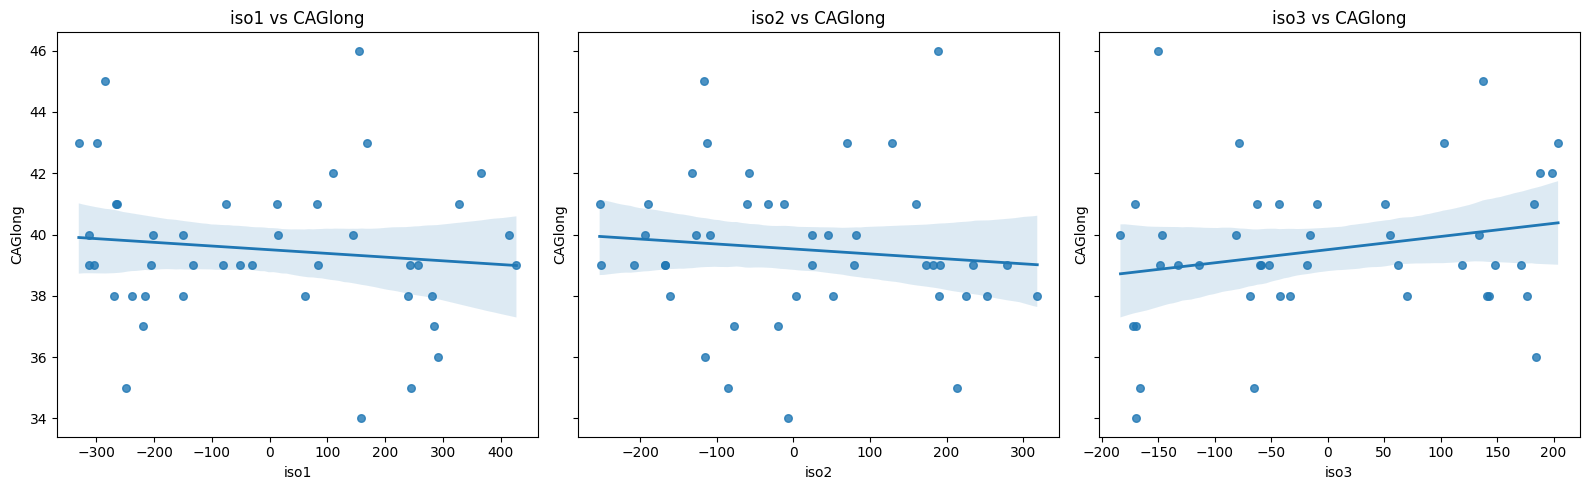

In [41]:
#####################  correlation plots  ###################

diag_measure = 'CAGlong'
shape_measures = ['iso1', 'iso2', 'iso3']

fig, axes = plt.subplots(1, len(shape_measures), figsize=(16, 5), sharey=True)

for ax, shape_measure in zip(axes, shape_measures):
    
    # Scatter with regression line
    sns.regplot(
        data=cur_info,
        x=shape_measure,
        y=diag_measure,
        ax=ax,
        scatter_kws={'s': 30},       # point size
        line_kws={'linewidth': 2}    # line thickness
    )
    
    ax.set_title(f'{shape_measure} vs {diag_measure}', fontsize=12)
    ax.set_xlabel(shape_measure)
    ax.set_ylabel(diag_measure)

plt.tight_layout()
plt.show()


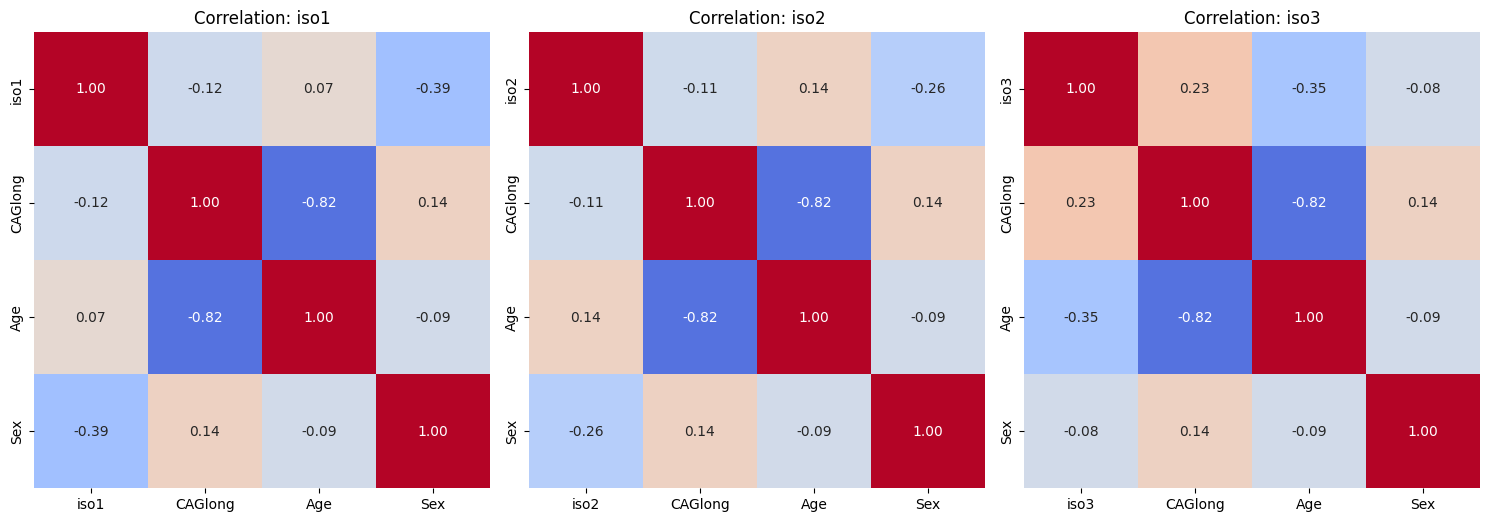

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

diag_measure = 'CAGlong'
shape_measures = ['iso1', 'iso2', 'iso3']

fig, axes = plt.subplots(1, len(shape_measures), figsize=(15, 5))

for ax, shape_measure in zip(axes, shape_measures):
    
    # Select relevant columns
    cols = [shape_measure, diag_measure, 'Age', 'Sex']
    corr = cur_info[cols].corr()
    
    # Plot heatmap
    sns.heatmap(
        corr, annot=True, cmap='coolwarm', center=0,
        ax=ax, fmt=".2f", square=True, cbar=False
    )
    
    ax.set_title(f'Correlation: {shape_measure}')

plt.tight_layout()
plt.show()
